In [1]:
import pandas as pd


Load Dataset

In [11]:
df=pd.read_excel("/content/Cleaned_Dataset.xlsx")

In [12]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [13]:
df.shape

(1189, 14)

In [14]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1189 entries, 0 to 1188
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1189 non-null   object        
 1   Date             1189 non-null   datetime64[ns]
 2   CustomerID       1189 non-null   object        
 3   Product          1189 non-null   object        
 4   Quantity         1189 non-null   int64         
 5   UnitPrice        1189 non-null   float64       
 6   ShippingAddress  1189 non-null   object        
 7   PaymentMethod    1189 non-null   object        
 8   OrderStatus      1189 non-null   object        
 9   TrackingNumber   1189 non-null   object        
 10  ItemsInCart      1189 non-null   int64         
 11  CouponCode       1189 non-null   object        
 12  ReferralSource   1189 non-null   object        
 13  TotalPrice       1189 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [16]:
df.duplicated().sum()

np.int64(0)

In [18]:
import numpy as np

In [19]:
numerics_columns=df.select_dtypes(include=np.number).columns

In [20]:
df[numerics_columns].count()

,0
Quantity,1189
UnitPrice,1189
ItemsInCart,1189
TotalPrice,1189


In [22]:
df[numerics_columns].mean().round(2)

,0
Quantity,2.94
UnitPrice,356.89
ItemsInCart,5.48
TotalPrice,1053.71


In [23]:
df[numerics_columns].median().round(2)

,0
Quantity,3.00
UnitPrice,364.42
ItemsInCart,5.00
TotalPrice,824.25


In [24]:
df[numerics_columns].min()

,0
Quantity,1.00
UnitPrice,11.39
ItemsInCart,1.00
TotalPrice,11.39


In [25]:
df[numerics_columns].max()

,0
Quantity,5.00
UnitPrice,699.93
ItemsInCart,10.00
TotalPrice,3456.40


Categorical Analysis

In [26]:
df["Product"].value_counts()

,count
Product,
Printer,179
Tablet,177
Chair,176
Laptop,172
Desk,170
Monitor,161
Phone,154


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

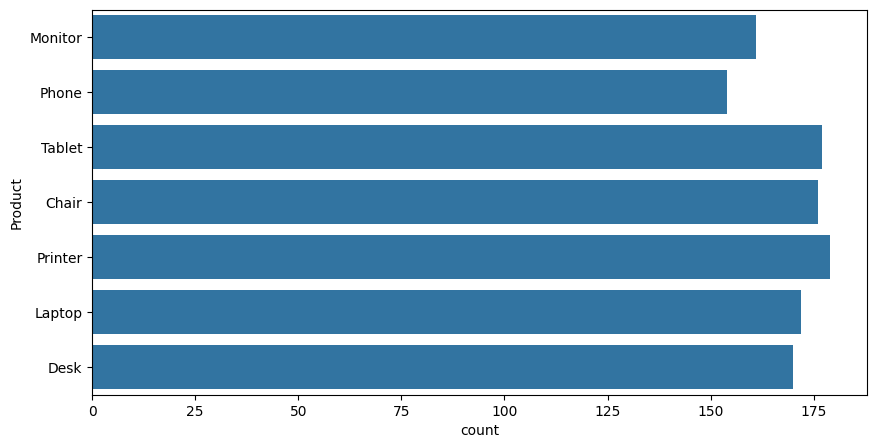

In [32]:
plt.figure(figsize=(10,5))
sns.countplot(df["Product"])
plt.show()

In [33]:
df["PaymentMethod"].value_counts()

,count
PaymentMethod,
Online,256
Cash,244
Credit Card,233
Debit Card,229
Gift Card,227


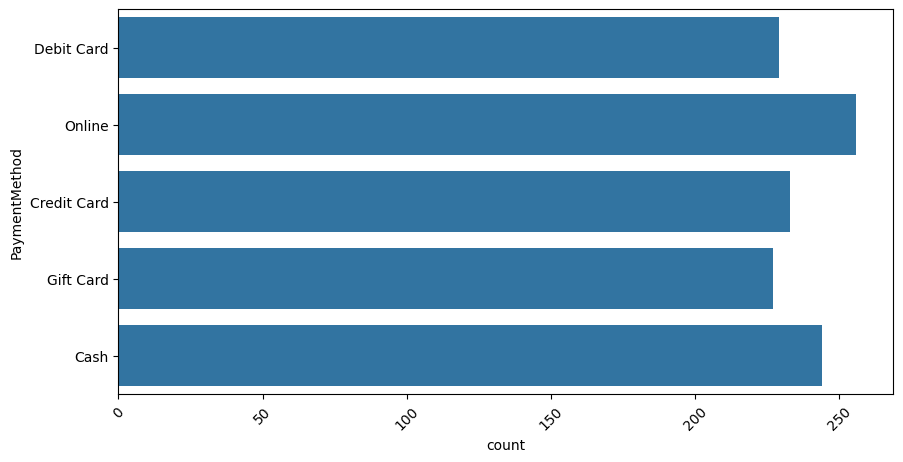

In [35]:
plt.figure(figsize=(10,5))
sns.countplot(df["PaymentMethod"])
plt.xticks(rotation=45)
plt.show()

In [36]:
df['OrderStatus'].value_counts()

,count
OrderStatus,
Cancelled,247
Returned,246
Shipped,233
Pending,233
Delivered,230


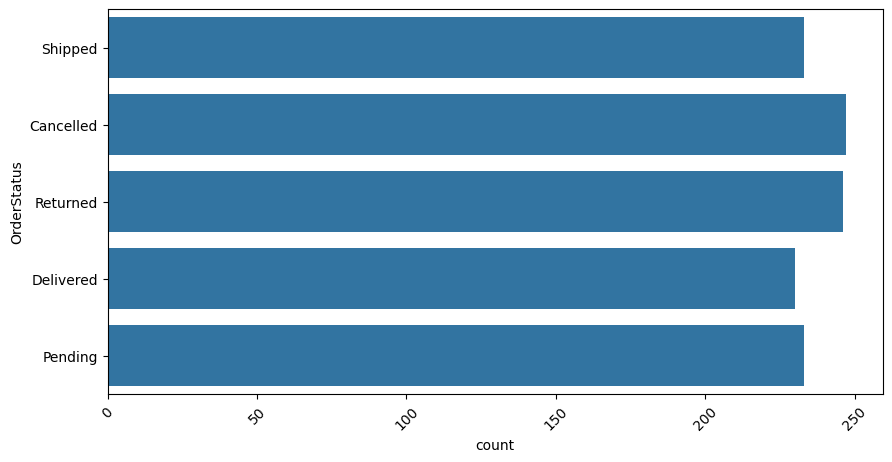

In [41]:
plt.figure(figsize=(10,5))
sns.countplot(df["OrderStatus"])
plt.xticks(rotation=45)
plt.show()

In [42]:
df["PaymentMethod"].value_counts()

,count
PaymentMethod,
Online,256
Cash,244
Credit Card,233
Debit Card,229
Gift Card,227


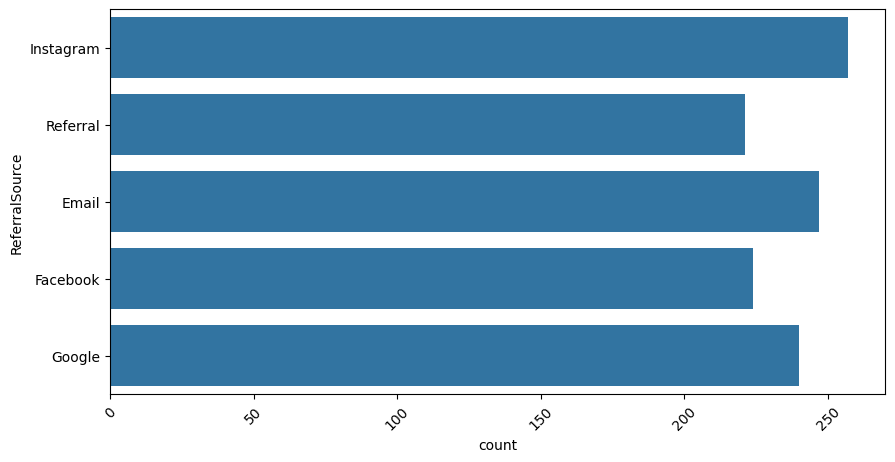

In [40]:
plt.figure(figsize=(10,5))
sns.countplot(df['ReferralSource'])
plt.xticks(rotation=45)
plt.show()

In [43]:
df["CouponCode"].value_counts()

,count
CouponCode,
FREESHIP,309
No Coupon,305
WINTER15,291
SAVE10,284


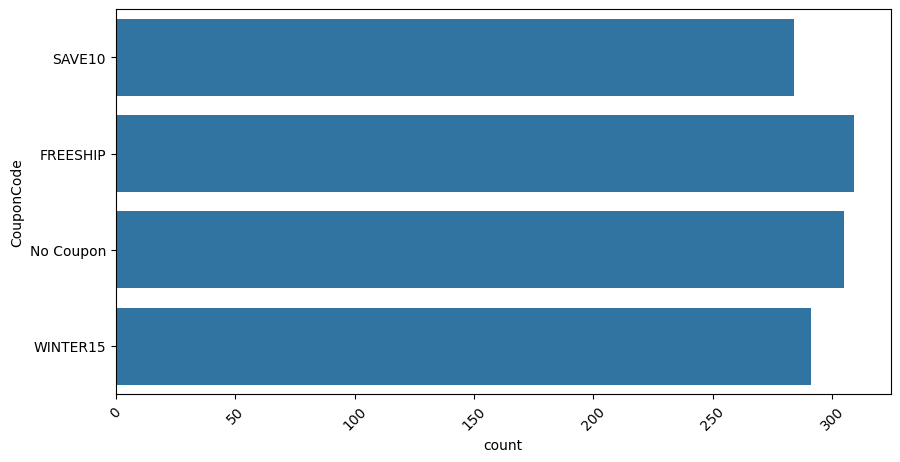

In [44]:
plt.figure(figsize=(10,5))
sns.countplot(df['CouponCode'])
plt.xticks(rotation=45)
plt.show()

Sales Analysis

In [45]:
df["TotalPrice"].sum()

np.float64(1252859.31)

In [46]:
df["TotalPrice"].max()

3456.4

In [47]:
df["TotalPrice"].min()

11.39

In [48]:
df["TotalPrice"].mean()

np.float64(1053.7084188393608)

In [49]:
df["TotalPrice"].median()

824.25

In [51]:
df["YearMonth"]=df['Date'].dt.to_period('M')
monthlysales=df.groupby("YearMonth")["TotalPrice"].sum()
display(monthlysales)

,TotalPrice
YearMonth,
2023-01,56685.75
2023-02,40117.66
2023-03,48609.37
2023-04,27751.71
2023-05,61454.36
2023-06,46109.24
2023-07,42262.16
2023-08,54352.14
2023-09,29526.67


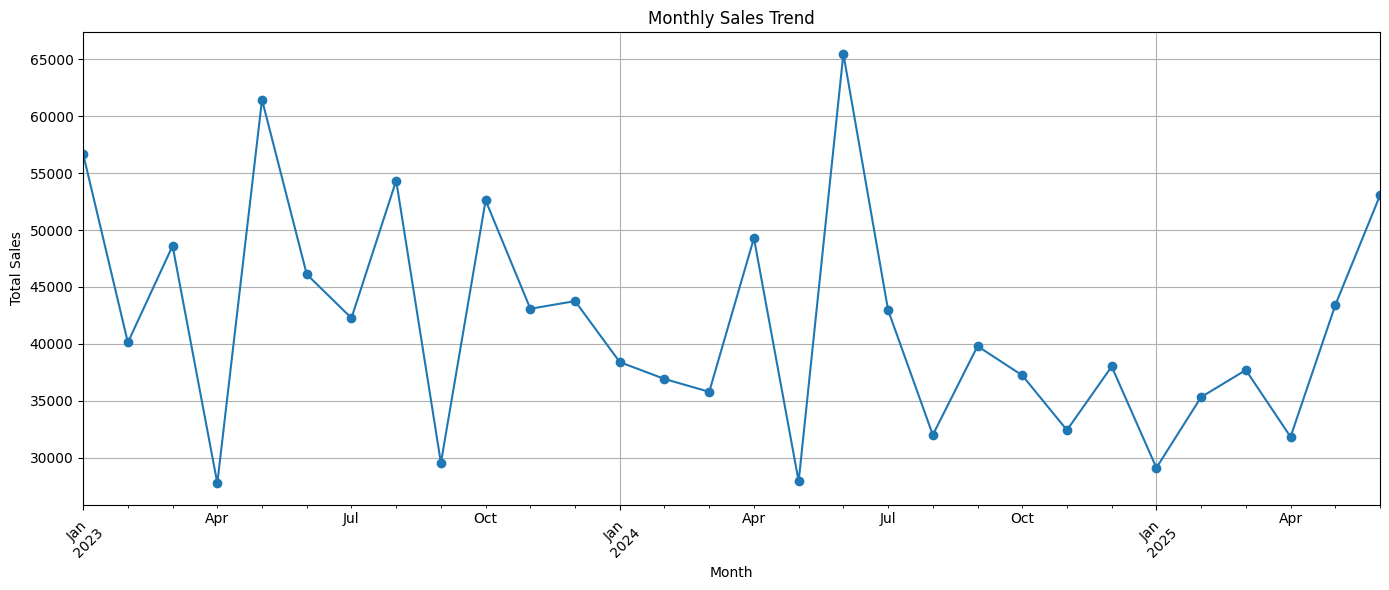

In [52]:
plt.figure(figsize=(14, 6))

monthlysales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

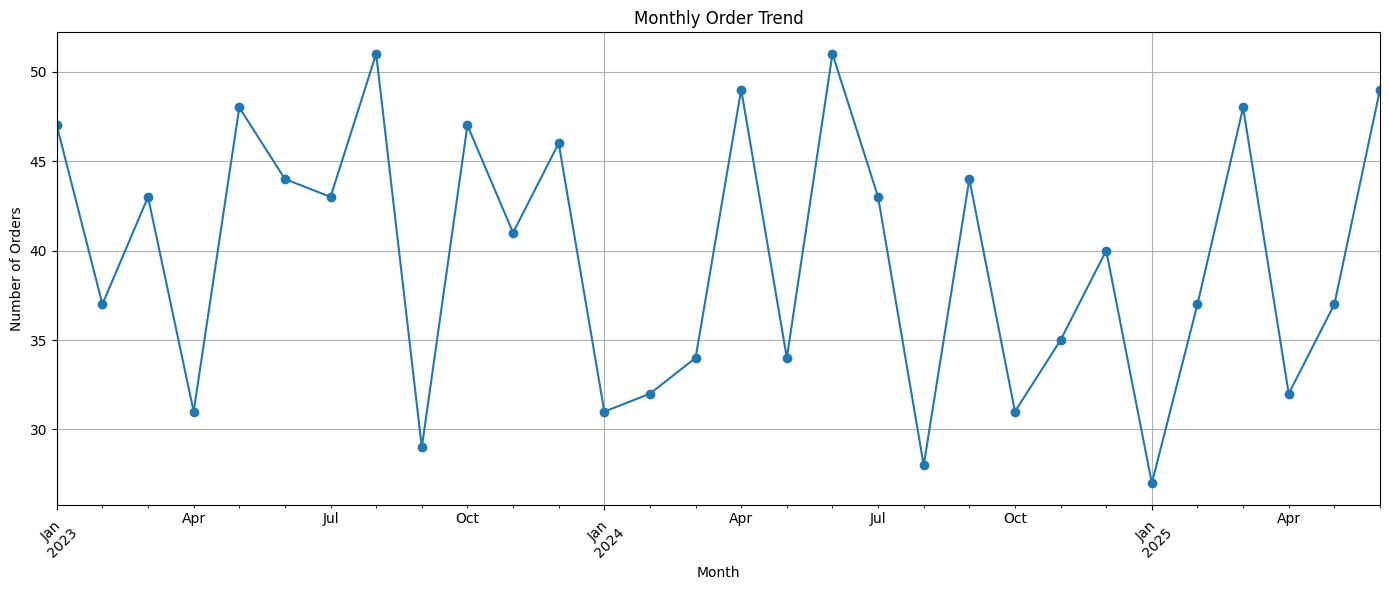

In [53]:
# ============================================================
# MONTHLY ORDER TREND
# ============================================================

monthly_orders = df.groupby('YearMonth')['OrderID'].count()

plt.figure(figsize=(14, 6))

monthly_orders.plot(kind='line', marker='o')

plt.title('Monthly Order Trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [54]:
# ============================================================
# YEARLY SALES ANALYSIS
# ============================================================

df['Year'] = df['Date'].dt.year

yearly_sales = df.groupby('Year')['TotalPrice'].sum()

print("Yearly Sales:")
display(yearly_sales)

Yearly Sales:


,TotalPrice
Year,
2023,546311.31
2024,476170.61
2025,230377.39


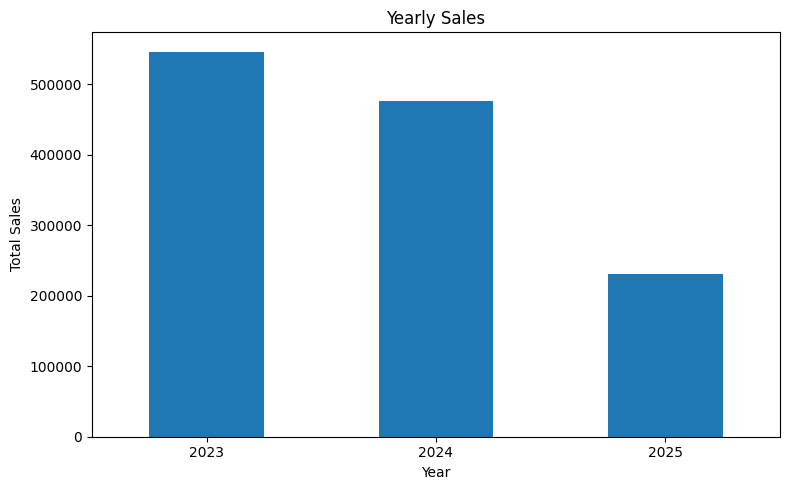

In [55]:
plt.figure(figsize=(8, 5))

yearly_sales.plot(kind='bar')

plt.title('Yearly Sales')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [56]:
# ============================================================
# QUANTITY ANALYSIS
# ============================================================

print("Quantity Statistics:")

print("Total Quantity Sold:", df['Quantity'].sum())
print("Average Quantity per Order:", df['Quantity'].mean())
print("Median Quantity:", df['Quantity'].median())
print("Maximum Quantity:", df['Quantity'].max())

Quantity Statistics:
Total Quantity Sold: 3498
Average Quantity per Order: 2.941968040370059
Median Quantity: 3.0
Maximum Quantity: 5


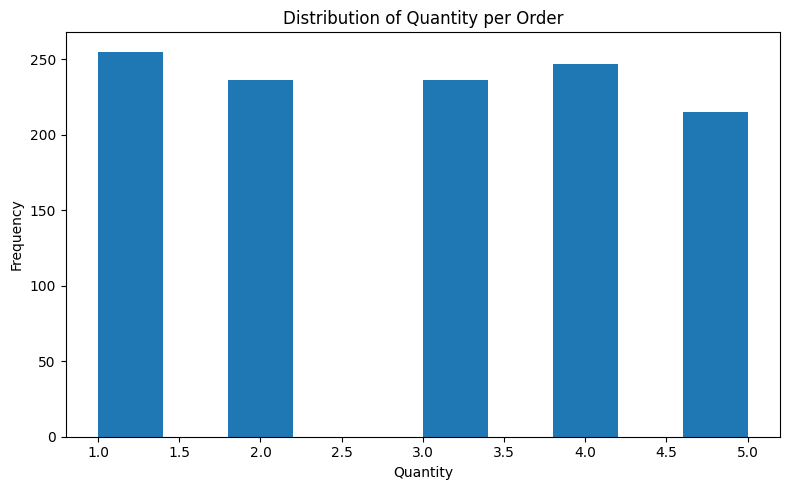

In [60]:
plt.figure(figsize=(8, 5))

plt.hist(df['Quantity'], bins=10)

plt.title('Distribution of Quantity per Order')
plt.xlabel('Quantity')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

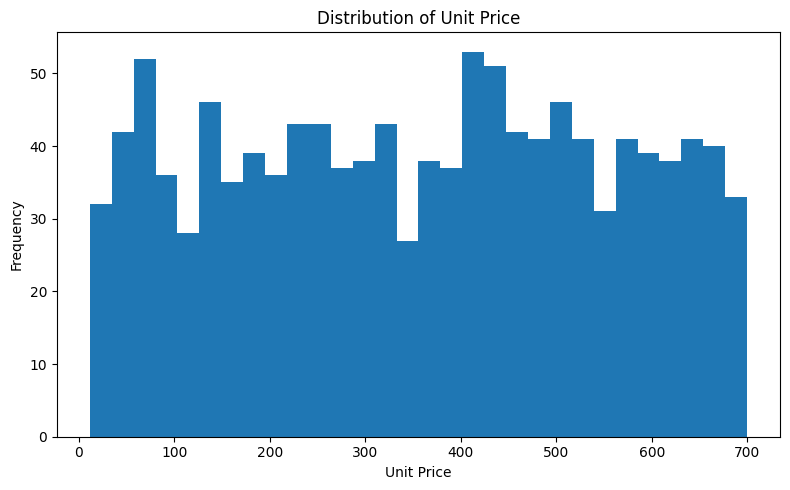

In [61]:
# ============================================================
# UNIT PRICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(df['UnitPrice'], bins=30)

plt.title('Distribution of Unit Price')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

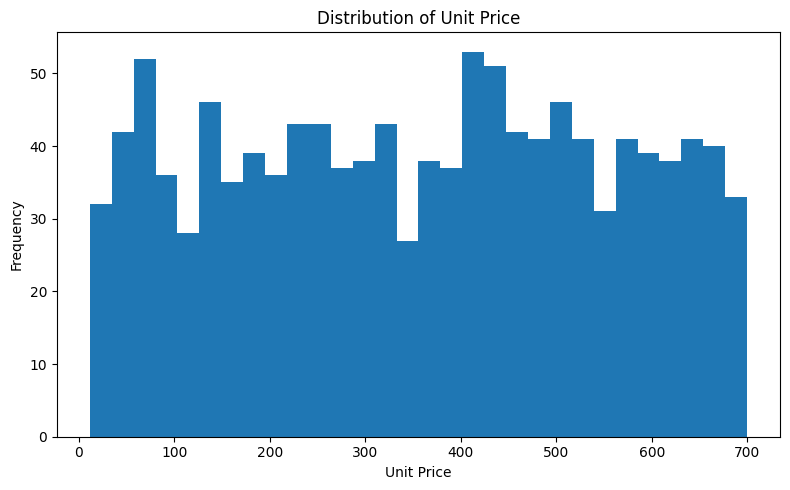

In [62]:
# ============================================================
# UNIT PRICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(df['UnitPrice'], bins=30)

plt.title('Distribution of Unit Price')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

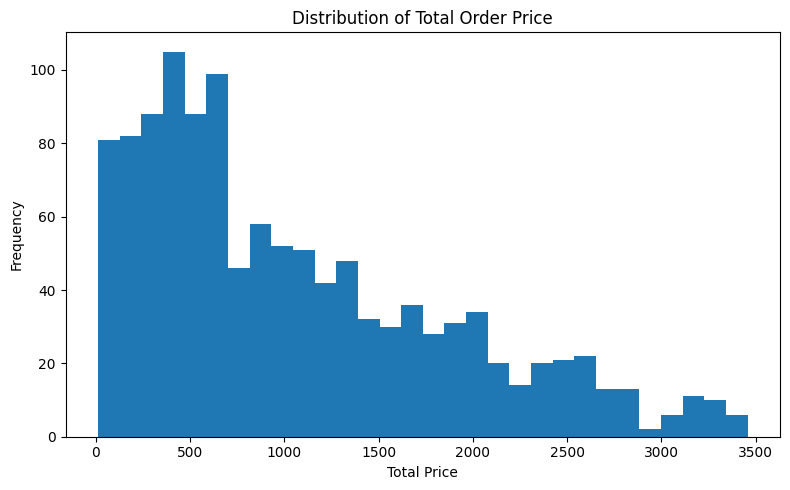

In [63]:
# ============================================================
# TOTAL PRICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(df['TotalPrice'], bins=30)

plt.title('Distribution of Total Order Price')
plt.xlabel('Total Price')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [64]:
# ============================================================
# OUTLIER DETECTION USING IQR
# ============================================================

def detect_outliers(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    print(f"\nColumn: {column}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Number of Outliers: {len(outliers)}")

    return outliers

In [65]:
# Detect outliers in important numerical variables

quantity_outliers = detect_outliers(df, 'Quantity')

unitprice_outliers = detect_outliers(df, 'UnitPrice')

cart_outliers = detect_outliers(df, 'ItemsInCart')

totalprice_outliers = detect_outliers(df, 'TotalPrice')


Column: Quantity
Q1: 2.00
Q3: 4.00
IQR: 2.00
Lower Bound: -1.00
Upper Bound: 7.00
Number of Outliers: 0

Column: UnitPrice
Q1: 187.88
Q3: 521.40
IQR: 333.52
Lower Bound: -312.40
Upper Bound: 1021.68
Number of Outliers: 0

Column: ItemsInCart
Q1: 4.00
Q3: 7.00
IQR: 3.00
Lower Bound: -0.50
Upper Bound: 11.50
Number of Outliers: 0

Column: TotalPrice
Q1: 410.60
Q3: 1580.35
IQR: 1169.75
Lower Bound: -1344.03
Upper Bound: 3334.97
Number of Outliers: 6


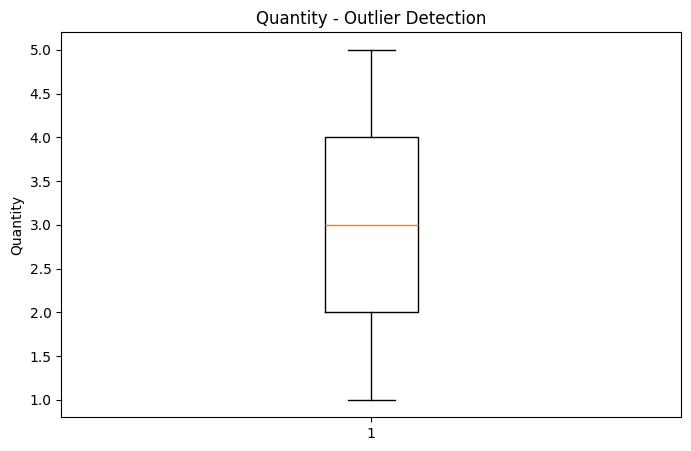

In [66]:
# ============================================================
# BOXPLOT - QUANTITY
# ============================================================

plt.figure(figsize=(8, 5))

plt.boxplot(df['Quantity'].dropna())

plt.title('Quantity - Outlier Detection')
plt.ylabel('Quantity')

plt.show()

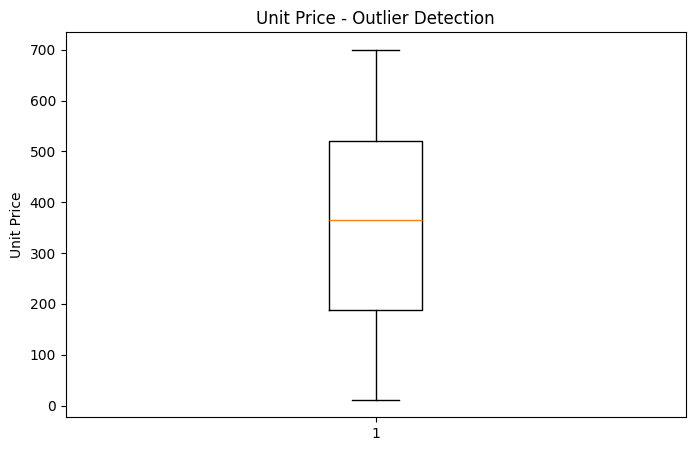

In [67]:
# ============================================================
# BOXPLOT - UNIT PRICE
# ============================================================

plt.figure(figsize=(8, 5))

plt.boxplot(df['UnitPrice'].dropna())

plt.title('Unit Price - Outlier Detection')
plt.ylabel('Unit Price')

plt.show()

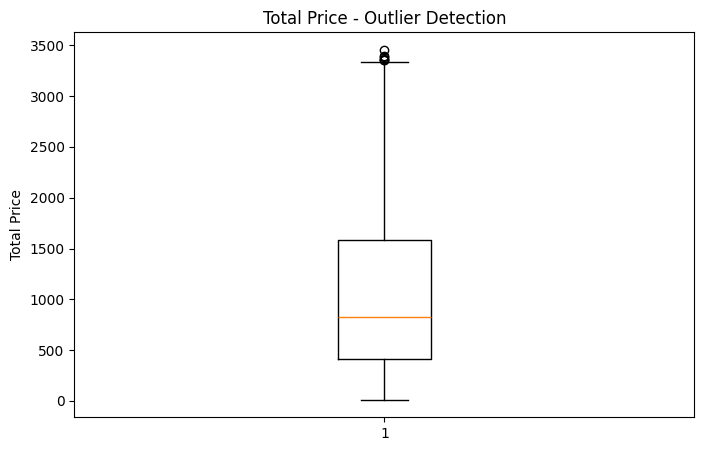

In [68]:
# ============================================================
# BOXPLOT - TOTAL PRICE
# ============================================================

plt.figure(figsize=(8, 5))

plt.boxplot(df['TotalPrice'].dropna())

plt.title('Total Price - Outlier Detection')
plt.ylabel('Total Price')

plt.show()

In [72]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

correlation_matrix = df[numerics_columns].corr()

print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.013527,0.649503,0.616856
UnitPrice,0.013527,1.000000,0.000252,0.714918
ItemsInCart,0.649503,0.000252,1.000000,0.392747
TotalPrice,0.616856,0.714918,0.392747,1.000000


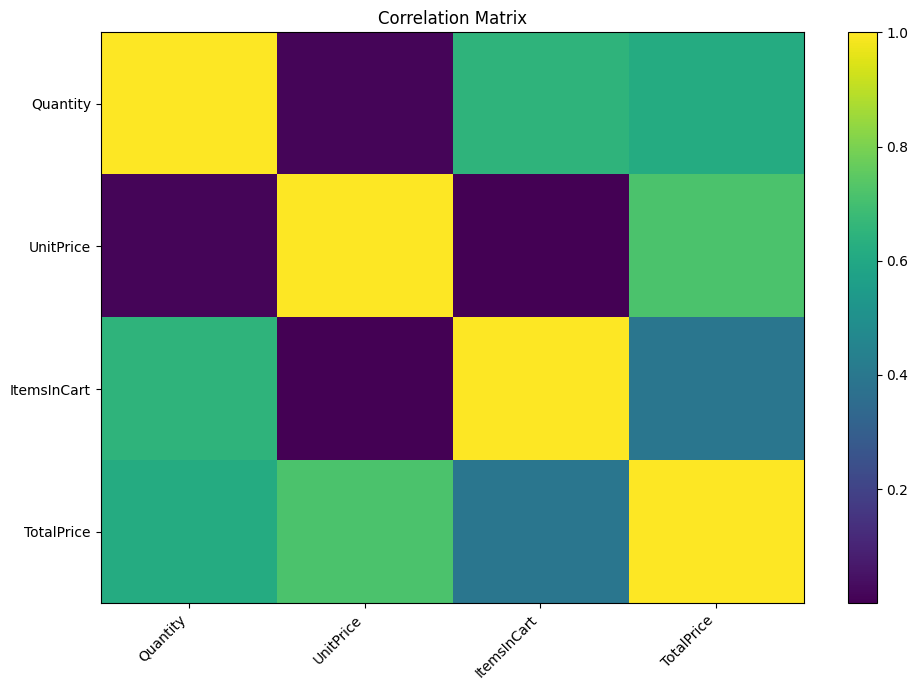

In [73]:
# ============================================================
# CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(10, 7))

plt.imshow(correlation_matrix, aspect='auto')

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

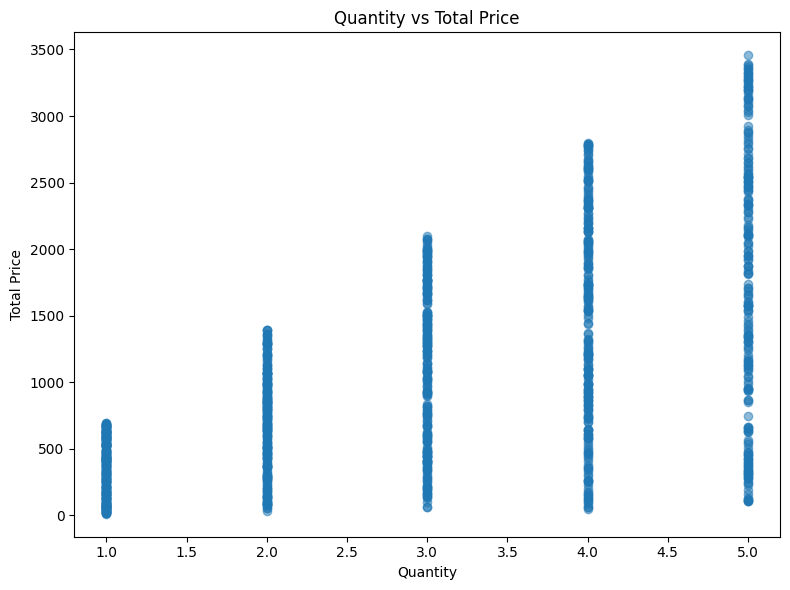

In [74]:
# ============================================================
# QUANTITY VS TOTAL PRICE
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    df['Quantity'],
    df['TotalPrice'],
    alpha=0.5
)

plt.title('Quantity vs Total Price')
plt.xlabel('Quantity')
plt.ylabel('Total Price')

plt.tight_layout()
plt.show()

In [75]:
# ============================================================
# SALES BY PRODUCT
# ============================================================

product_sales = (
    df.groupby('Product')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
)

print("Sales by Product:")
display(product_sales)

Sales by Product:


,TotalPrice
Product,
Chair,192725.97
Printer,192671.63
Laptop,191347.56
Tablet,186327.99
Monitor,172113.94
Desk,167459.93
Phone,150212.29


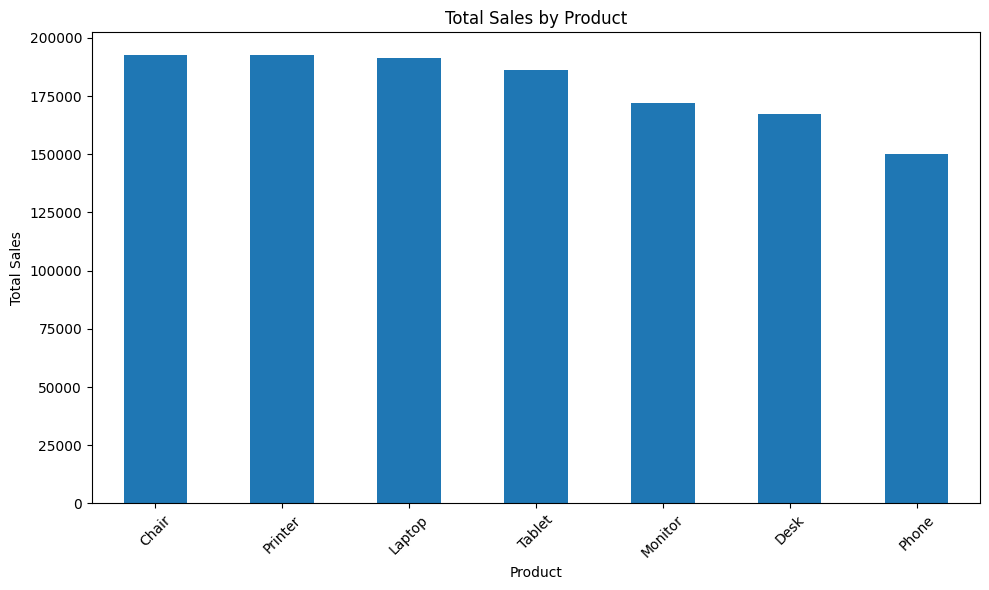

In [76]:
plt.figure(figsize=(10, 6))

product_sales.plot(kind='bar')

plt.title('Total Sales by Product')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [77]:
# ============================================================
# AVERAGE ORDER VALUE BY PRODUCT
# ============================================================

product_average = (
    df.groupby('Product')['TotalPrice']
    .mean()
    .sort_values(ascending=False)
)

print("Average Order Value by Product:")
display(product_average)

Average Order Value by Product:


,TotalPrice
Product,
Laptop,1112.485814
Chair,1095.033920
Printer,1076.377821
Monitor,1069.030683
Tablet,1052.700508
Desk,985.058412
Phone,975.404481


In [78]:
# ============================================================
# SALES BY REFERRAL SOURCE
# ============================================================

referral_sales = (
    df.groupby('ReferralSource')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
)

print("Sales by Referral Source:")
display(referral_sales)

Sales by Referral Source:


,TotalPrice
ReferralSource,
Instagram,273792.61
Email,259607.79
Google,249253.34
Facebook,243711.95
Referral,226493.62


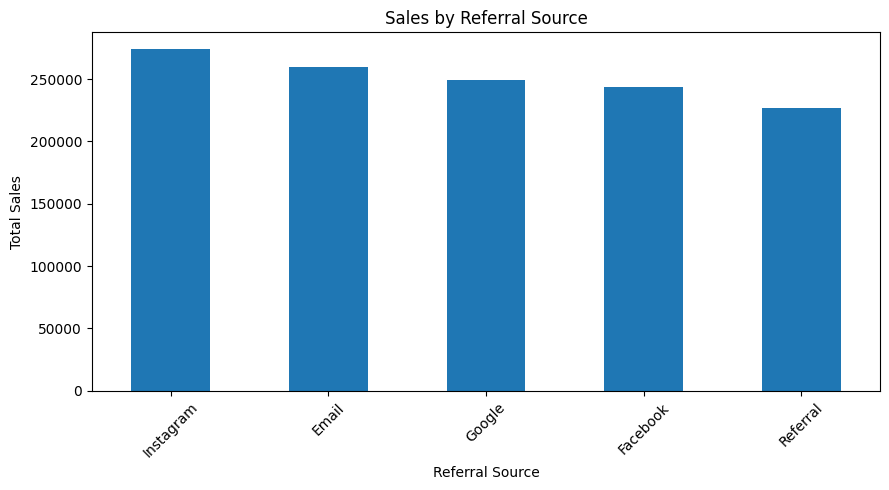

In [79]:
plt.figure(figsize=(9, 5))

referral_sales.plot(kind='bar')

plt.title('Sales by Referral Source')
plt.xlabel('Referral Source')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [80]:
# ============================================================
# FINAL EDA SUMMARY
# ============================================================

print("=" * 60)
print("EXPLORATORY DATA ANALYSIS - FINAL SUMMARY")
print("=" * 60)

print(f"\nTotal Number of Orders: {len(df):,}")

print(f"Total Sales: ${df['TotalPrice'].sum():,.2f}")

print(f"Average Order Value: ${df['TotalPrice'].mean():,.2f}")

print(f"Median Order Value: ${df['TotalPrice'].median():,.2f}")

print(f"Total Quantity Sold: {df['Quantity'].sum():,}")

print(f"Average Quantity per Order: {df['Quantity'].mean():.2f}")

print(f"Most Popular Product: {df['Product'].mode()[0]}")

print(f"Most Used Payment Method: {df['PaymentMethod'].mode()[0]}")

print(f"Most Common Order Status: {df['OrderStatus'].mode()[0]}")

print(f"Most Common Referral Source: {df['ReferralSource'].mode()[0]}")

print(f"Orders Using Coupons: {df['CouponCode'].notna().sum():,}")

print(f"Orders Without Coupons: {df['CouponCode'].isna().sum():,}")

print(f"Quantity Outliers: {len(quantity_outliers):,}")

print(f"Unit Price Outliers: {len(unitprice_outliers):,}")

print(f"Total Price Outliers: {len(totalprice_outliers):,}")

print("=" * 60)

EXPLORATORY DATA ANALYSIS - FINAL SUMMARY

Total Number of Orders: 1,189
Total Sales: $1,252,859.31
Average Order Value: $1,053.71
Median Order Value: $824.25
Total Quantity Sold: 3,498
Average Quantity per Order: 2.94
Most Popular Product: Printer
Most Used Payment Method: Online
Most Common Order Status: Cancelled
Most Common Referral Source: Instagram
Orders Using Coupons: 1,189
Orders Without Coupons: 0
Quantity Outliers: 0
Unit Price Outliers: 0
Total Price Outliers: 6
